# Discrete-event simulation report

M/M/c and Ross model

## Цель

Собрать итоговые результаты для моделей `M/M/c` и Росса, сравнить
имитационные и аналитические значения.

## Подготовка

In [1]:
using DrWatson
@quickactivate "project"

using CSV
using DataFrames
using Plots

## Сводная таблица

In [2]:
mmc_summary = CSV.read(datadir("mmc_summary.csv"), DataFrame)
ross_summary = CSV.read(datadir("ross_summary.csv"), DataFrame)
ross_scan = CSV.read(datadir("ross_scan.csv"), DataFrame)

summary = DataFrame(
    model = ["M/M/c", "Ross"],
    main_metric = ["mean waiting time", "mean crash time"],
    simulation = [mmc_summary.mean_waiting_time[1], ross_summary.mean_crash_time[1]],
    analytic = [mmc_summary.theoretical_wq[1], ross_summary.analytic_crash_time[1]],
)

CSV.write(datadir("des_summary.csv"), summary)
summary

## Сравнение с аналитикой


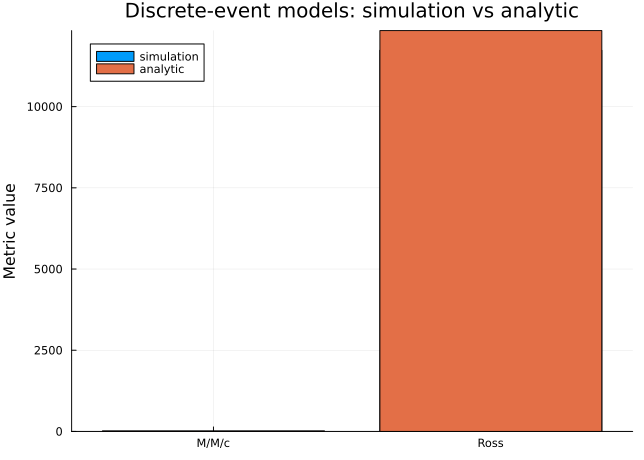

In [3]:
plt = bar(
    summary.model,
    [summary.simulation summary.analytic],
    label = ["simulation" "analytic"],
    ylabel = "Metric value",
    title = "Discrete-event models: simulation vs analytic",
)
savefig(plt, plotsdir("des_simulation_vs_analytic.png"))
plt

## Лучшие конфигурации

In [4]:
best = combine(groupby(ross_scan, [:machines, :repairers]), :mean_crash_time => maximum => :best_crash_time)
CSV.write(datadir("ross_best_by_configuration.csv"), best)
best

## Вывод

Итоговые таблицы и графики показывают, что дискретно-событийное
моделирование позволяет оценивать как очереди обслуживания, так и
надежность систем с резервированием и ремонтом.